# Анализ набора данных NSL-KDD для бинарного обнаружения сетевых аномалий

## Введение

В области кибербезопасности и систем обнаружения вторжений (IDS) набор данных NSL-KDD занимает позицию эталонного ресурса для оценки производительности моделей машинного обучения. Этот набор данных, производный от оригинального KDD Cup 1999, устраняет присущие его предшественнику ограничения и смещения, что делает его жизненно важным инструментом для исследователей и практиков в сфере IDS.

Данная работа представляет собой комплексное исследование набора данных NSL-KDD, сфокусированное на построении и оценке моделей машинного обучения для задачи **бинарного выявления аномалий** (классификация трафика на «норма» и «атака»). Ключевые цели и этапы данного проекта включают:

1.  **Импорт библиотек и глобальные настройки:** Загрузка необходимых Python-библиотек, таких как `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` и `xgboost`, а также настройка окружения для анализа (отключение предупреждений, стиль графиков).

2.  **Загрузка и первичный осмотр данных:** Загрузка наборов данных `KDDTrain+` и `KDDTest+` из NSL-KDD, первичный анализ структуры и содержимого с помощью методов `.info()`, `.head()`, а также изучение исходного распределения классов.

3.  **Предварительная очистка и проверка данных:** Операции по очистке данных, включая проверку и удаление дубликатов, подтверждение отсутствия пропущенных значений и приведение типов данных колонок к корректному формату, подготавливая данные для дальнейшего анализа.

4.  **Преобразование меток:** Унификация различных типов атак в единую категорию «anomaly», при этом метка «normal» остается неизменной. Последующее кодирование целевой переменной в бинарный формат (например, 0 для «normal» и 1 для «anomaly»).

5.  **Исследовательский анализ данных (EDA) и визуализация:** Применение техник EDA для получения инсайтов о структуре датасета, распределении признаков (включая применение логарифмического преобразования для скошенных данных), корреляциях и потенциальных закономерностях, что помогает понять характеристики сетевого трафика и аномального поведения.

6.  **Формирование препроцессинга:** Разработка конвейера предварительной обработки данных, включающего кодирование категориальных признаков (например, `OneHotEncoder`) и масштабирование числовых признаков (например, `StandardScaler` или `MinMaxScaler`) с использованием `ColumnTransformer`.

7.  **Разделение данных и стратегия валидации:** Разделение обучающей выборки `KDDTrain+` на обучающий и валидационный наборы со стратификацией или использование стратифицированной кросс-валидации (`StratifiedKFold`) для надежной оценки моделей.

8.  **Выбор, настройка и обучение моделей:**
    *   **Логистическая регрессия:** Используется как простая и интерпретируемая базовая модель для бинарной классификации.
    *   **Наивный Байес (GaussianNB):** Применяется для вероятностной классификации, основанной на теореме Байеса.
    *   **Метод опорных векторов (SVM):** Рассматривается как `One-Class SVM` для обнаружения аномалий (без учителя) и/или линейный `SVC` для классификационной задачи.
    *   **Случайный лес (Random Forest):** Ансамблевый метод, известный своей устойчивостью к переобучению и высокой производительностью.
    *   **XGBoost:** Мощный алгоритм градиентного бустинга, часто демонстрирующий передовые результаты в задачах классификации.
    *   **Isolation Forest:** Эффективный метод для обнаружения аномалий без учителя, хорошо подходящий для многомерных данных.
    *   **(Опционально) Автоэнкодер:** Исследование возможностей глубокого обучения для выявления сложных нелинейных зависимостей и аномалий.
    Для каждой модели предполагается подбор гиперпараметров с использованием `GridSearchCV` или `RandomizedSearchCV` с целевой метрикой `ROC AUC`.

9.  **Оценка моделей на валидационном и тестовом наборах:** Оценка производительности моделей с использованием метрик, таких как `ROC AUC`, `PR AUC` (площадь под кривой Precision-Recall), а также `precision`, `recall` и `F1-score` (особенно для класса «аномалия»). Построение ROC-кривых и PR-кривых.

10. **Анализ важности признаков:** Идентификация ключевых признаков, вносящих наибольший вклад в обнаружение аномалий, с помощью коэффициентов моделей или атрибута `feature_importances_`.

11. **Анализ результатов и выводы:** Представление сильных и слабых сторон различных моделей машинного обучения, обсуждение полученных результатов и формулирование рекомендаций по улучшению стратегий обнаружения сетевых вторжений и возможных направлений дальнейшей работы (например, балансировка классов, ансамблирование).

Данное исследование набора данных NSL-KDD направлено на изучение сложностей бинарного обнаружения сетевых аномалий, используя методы машинного обучения для усиления защиты от киберугроз.

# Введение и постановка задачи

-   Описать цель: бинарное выявление аномалий («норма» vs «атака») в сетевом трафике.
-   Обосновать выбор `NSL-KDD` и формулировку задачи.

# Импорт библиотек и глобальные настройки

-   `numpy`, `pandas`, `scikit-learn`, `xgboost`, `matplotlib` и пр.
-   Отключить предупреждения, задать стиль графиков и формат числа.

# Загрузка и первичный осмотр данных

-   Относительные пути к `KDDTrain+` и `KDDTest+`.
-   Указать `header=None` и `names=COLUMN_NAMES` при загрузке.
-   Вызовы `.info()`, `.head()`.
-   Анализ распределения классов.

# Предварительная очистка и проверка

-   Проверить и удалить дубликаты.
-   Убедиться в отсутствии пропусков.
-   Привести колонки к нужным типам данных.

# Преобразование меток

-   Свести все нестандартные метки атак к «anomaly».
-   Метку «normal» оставить без изменений.
-   Закодировать целевую переменную (например, `0 = normal`, `1 = anomaly`).

# EDA (Exploratory Data Analysis)

-   Распределение классов.
-   `histogram` & `boxplot` для ключевых числовых признаков.
-   Логарифмическое преобразование для признаков с высокой асимметрией (`skewed`).
-   Корреляционная матрица для числовых признаков (`numerical features`).
-   Анализ категориальных признаков.

# Формирование препроцессинга

-   Для категориальных признаков (`cat_features`): `OneHotEncoder(handle_unknown='ignore')`.
-   Для числовых признаков (`num_features`): `StandardScaler` (или `MinMaxScaler`).
-   Использовать `ColumnTransformer` для объединения шагов препроцессинга.

# Внутренний сплит и кросс-валидация

-   Разбить `KDDTrain+` на обучающую и валидационную выборки (например, `80/20`, использовать стратификацию).
-   Либо использовать `StratifiedKFold(n_splits=5)` для кросс-валидации.

# Выбор и настройка моделей

Использовать `GridSearchCV` или `RandomizedSearchCV` для подбора ключевых гиперпараметров. Основная метрика для оптимизации – `ROC AUC`.

-   **Логистическая регрессия**
-   **Наивный Байес** (`GaussianNB`)
-   **SVM**:
    -   `One-Class SVM` (для поиска аномалий, unsupervised)
    -   Линейный `SVC` (для классификации)
-   **Random Forest**
-   **XGBoost**
-   **Isolation Forest** (unsupervised anomaly detection)
-   **Автоэнкодер** (например, на основе `TensorFlow/Keras` или `PyTorch`, если рассматриваются глубинные методы)

# Оценка на валидационном наборе

-   **Метрики**:
    -   `ROC AUC`
    -   `PR AUC` (Precision-Recall AUC)
    -   `precision`, `recall`, `F1-score` для класса «аномалия».
-   Построить ROC-кривые и Precision-Recall-кривые для всех моделей.
-   Сравнить модели по основным метрикам и времени обучения.

# Финальное обучение и тестирование

-   Обучить выбранную(ые) лучшую(ие) модель(и) на полном наборе `KDDTrain+`.
-   Оценить на `KDDTest+`:
    -   Матрица ошибок (`confusion matrix`).
    -   Отчет о классификации (`classification_report`).
    -   `ROC AUC`, `PR AUC`.

# Анализ результатов и визуализация

-   Сводная таблица метрик для всех моделей на тестовом наборе.
-   ROC- и PR-кривые в одном графике для наглядного сравнения моделей.
-   Важность признаков:
    -   Коэффициенты для Логистической регрессии.
    -   `feature_importances_` для `Random Forest` / `XGBoost`.

# Выводы и дальнейшие направления

-   Сравнить сильные и слабые стороны протестированных моделей.
-   **Предложения по улучшению/развитию**:
    -   Балансировка классов (например, `SMOTE`).
    -   Ансамблирование моделей.
    -   Разработка системы онлайн-детектирования.
    -   Более глубокое исследование автоэнкодеров (если они показали перспективу).

# 1.Импорт библиотек.

In [3]:
pip install --upgrade pip

  Using cached pip-25.1.1-py3-none-any.whl.metadata (3.6 kB)
Using cached pip-25.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import time
import joblib
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC #, OneClassSVM # OneClassSVM пока закомментируем, добавим позже если нужно
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, classification_report, confusion_matrix, roc_curve
from sklearn.metrics import f1_score, precision_score, recall_score

# Библиотеки для нейросетей (если будем использовать, например автоэнкодер)
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, Callback

# Для SMOTE, если потребуется
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from pathlib import Path
import warnings

%matplotlib inline
warnings.filterwarnings('ignore') # Отключаем предупреждения для чистоты вывода
plt.style.use('seaborn-v0_8-whitegrid') # Стиль графиков
pd.set_option('display.max_columns', None) # Отображать все колонки pandas
pd.set_option('display.float_format', '{:.3f}'.format) # Формат чисел с плавающей точкой

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/andreyserba/Desktop/Курсач 2025/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: '@rpath/libomp.dylib'\n  Referenced from: '/Users/andreyserba/Desktop/Курсач 2025/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib'\n  Reason: tried: '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/usr/local/lib/libomp.dylib' (no such file), '/usr/lib/libomp.dylib' (no such file)"]


# 2. Загрузка и первичный осмотр данных.

In [ ]:
DATA_DIR = Path('/Users/andreyserba/Desktop/Курсач 2025/')
train_file = 'KDDTrain+.txt'
test_file  = 'KDDTest+.txt'

In [ ]:
# Список имён колонок (41 признак + метка + сложность)
COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "anomaly", "level"
]

data_train = pd.read_csv(train_file, names=COLUMN_NAMES)
data_test  = pd.read_csv(test_file,  names=COLUMN_NAMES)

### 2.1 Обзор тренировочного набора данных.

In [ ]:
data_train.info()
print("\nПервые 5 строк:")
display(data_train.head())
print("\nРаспределение классов ('label'):")
print(data_train['anomaly'].value_counts())
print(f"\nРазмер: {data_train.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,anomaly,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.000,0.000,0.000,0.000,1.000,0.000,0.000,150,25,0.170,0.030,0.170,0.000,0.000,0.000,0.050,0.000,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.000,0.000,0.000,0.000,0.080,0.150,0.000,255,1,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.000,1.000,0.000,0.000,0.050,0.070,0.000,255,26,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.200,0.200,0.000,0.000,1.000,0.000,0.000,30,255,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.000,0.000,0.000,0.000,1.000,0.000,0.090,255,255,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal,21



Распределение классов ('label'):
anomaly
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Размер: (125973, 43)


In [ ]:
data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.000,287.145,2604.515,0.000,0.000,0.000,0.000,42908.000
src_bytes,125973.000,45566.743,5870331.182,0.000,0.000,44.000,276.000,1379963888.000
dst_bytes,125973.000,19779.114,4021269.151,0.000,0.000,0.000,516.000,1309937401.000
land,125973.000,0.000,0.014,0.000,0.000,0.000,0.000,1.000
wrong_fragment,125973.000,0.023,0.254,0.000,0.000,0.000,0.000,3.000
urgent,125973.000,0.000,0.014,0.000,0.000,0.000,0.000,3.000
hot,125973.000,0.204,2.150,0.000,0.000,0.000,0.000,77.000
num_failed_logins,125973.000,0.001,0.045,0.000,0.000,0.000,0.000,5.000
logged_in,125973.000,0.396,0.489,0.000,0.000,0.000,1.000,1.000
num_compromised,125973.000,0.279,23.942,0.000,0.000,0.000,0.000,7479.000


### 2.2 Обзор тестовго набора данных.

In [ ]:
data_test.info()
print("\nПервые 5 строк:")
display(data_test.head())
print("\nРаспределение классов ('label'):")
print(data_test['anomaly'].value_counts())
print(f"\nРазмер: {data_test.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell      

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,anomaly,level
0,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,229,10,0.000,0.000,1.000,1.000,0.040,0.060,0.000,255,10,0.040,0.060,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,136,1,0.000,0.000,1.000,1.000,0.010,0.060,0.000,255,1,0.000,0.060,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.000,0.000,0.000,0.000,1.000,0.000,0.000,134,86,0.610,0.040,0.610,0.020,0.000,0.000,0.000,0.000,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,65,0.000,0.000,0.000,0.000,1.000,0.000,1.000,3,57,1.000,0.000,1.000,0.280,0.000,0.000,0.000,0.000,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8,0.000,0.120,1.000,0.500,1.000,0.000,0.750,29,86,0.310,0.170,0.030,0.020,0.000,0.000,0.830,0.710,mscan,11



Распределение классов ('label'):
anomaly
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
portsweep           157
ipsweep             141
httptunnel          133
nmap                 73
pod                  41
buffer_overflow      20
multihop             18
named                17
ps                   15
sendmail             14
xterm                13
rootkit              13
teardrop             12
xlock                 9
land                  7
xsnoop                4
ftp_write             3
loadmodule            2
worm                  2
perl                  2
sqlattack             2
udpstorm              2
phf                   2
imap                  1
Name: count, dtype: int64

Размер: (22544, 43)

# 3. Предварительная очистка и проверка.
### Предобрабатываем только train datase, так как

In [ ]:
data_train.duplicated().sum()

np.int64(0)

In [ ]:
data_train.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [ ]:
#helper function for deeper analysis
def unique_values(data, columns):
    """Prints unique values and their counts for specific columns in the DataFrame."""

    for column_name in columns:
        print(f"Column: {column_name}\n{'-'*30}")
        unique_vals = data[column_name].unique()
        value_counts = data[column_name].value_counts()
        print(f"Unique Values ({len(unique_vals)}): {unique_vals}\n")
        print(f"Value Counts:\n{value_counts}\n{'='*40}\n")

In [ ]:
cat_features = data_train.select_dtypes(include='object').columns
unique_values(data_train, cat_features)

Column: protocol_type
------------------------------
Unique Values (3): ['tcp' 'udp' 'icmp']

Value Counts:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

Column: service
------------------------------
Unique Values (70): ['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

Value Counts:
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
 

<Figure size 2000x4000 with 0 Axes>

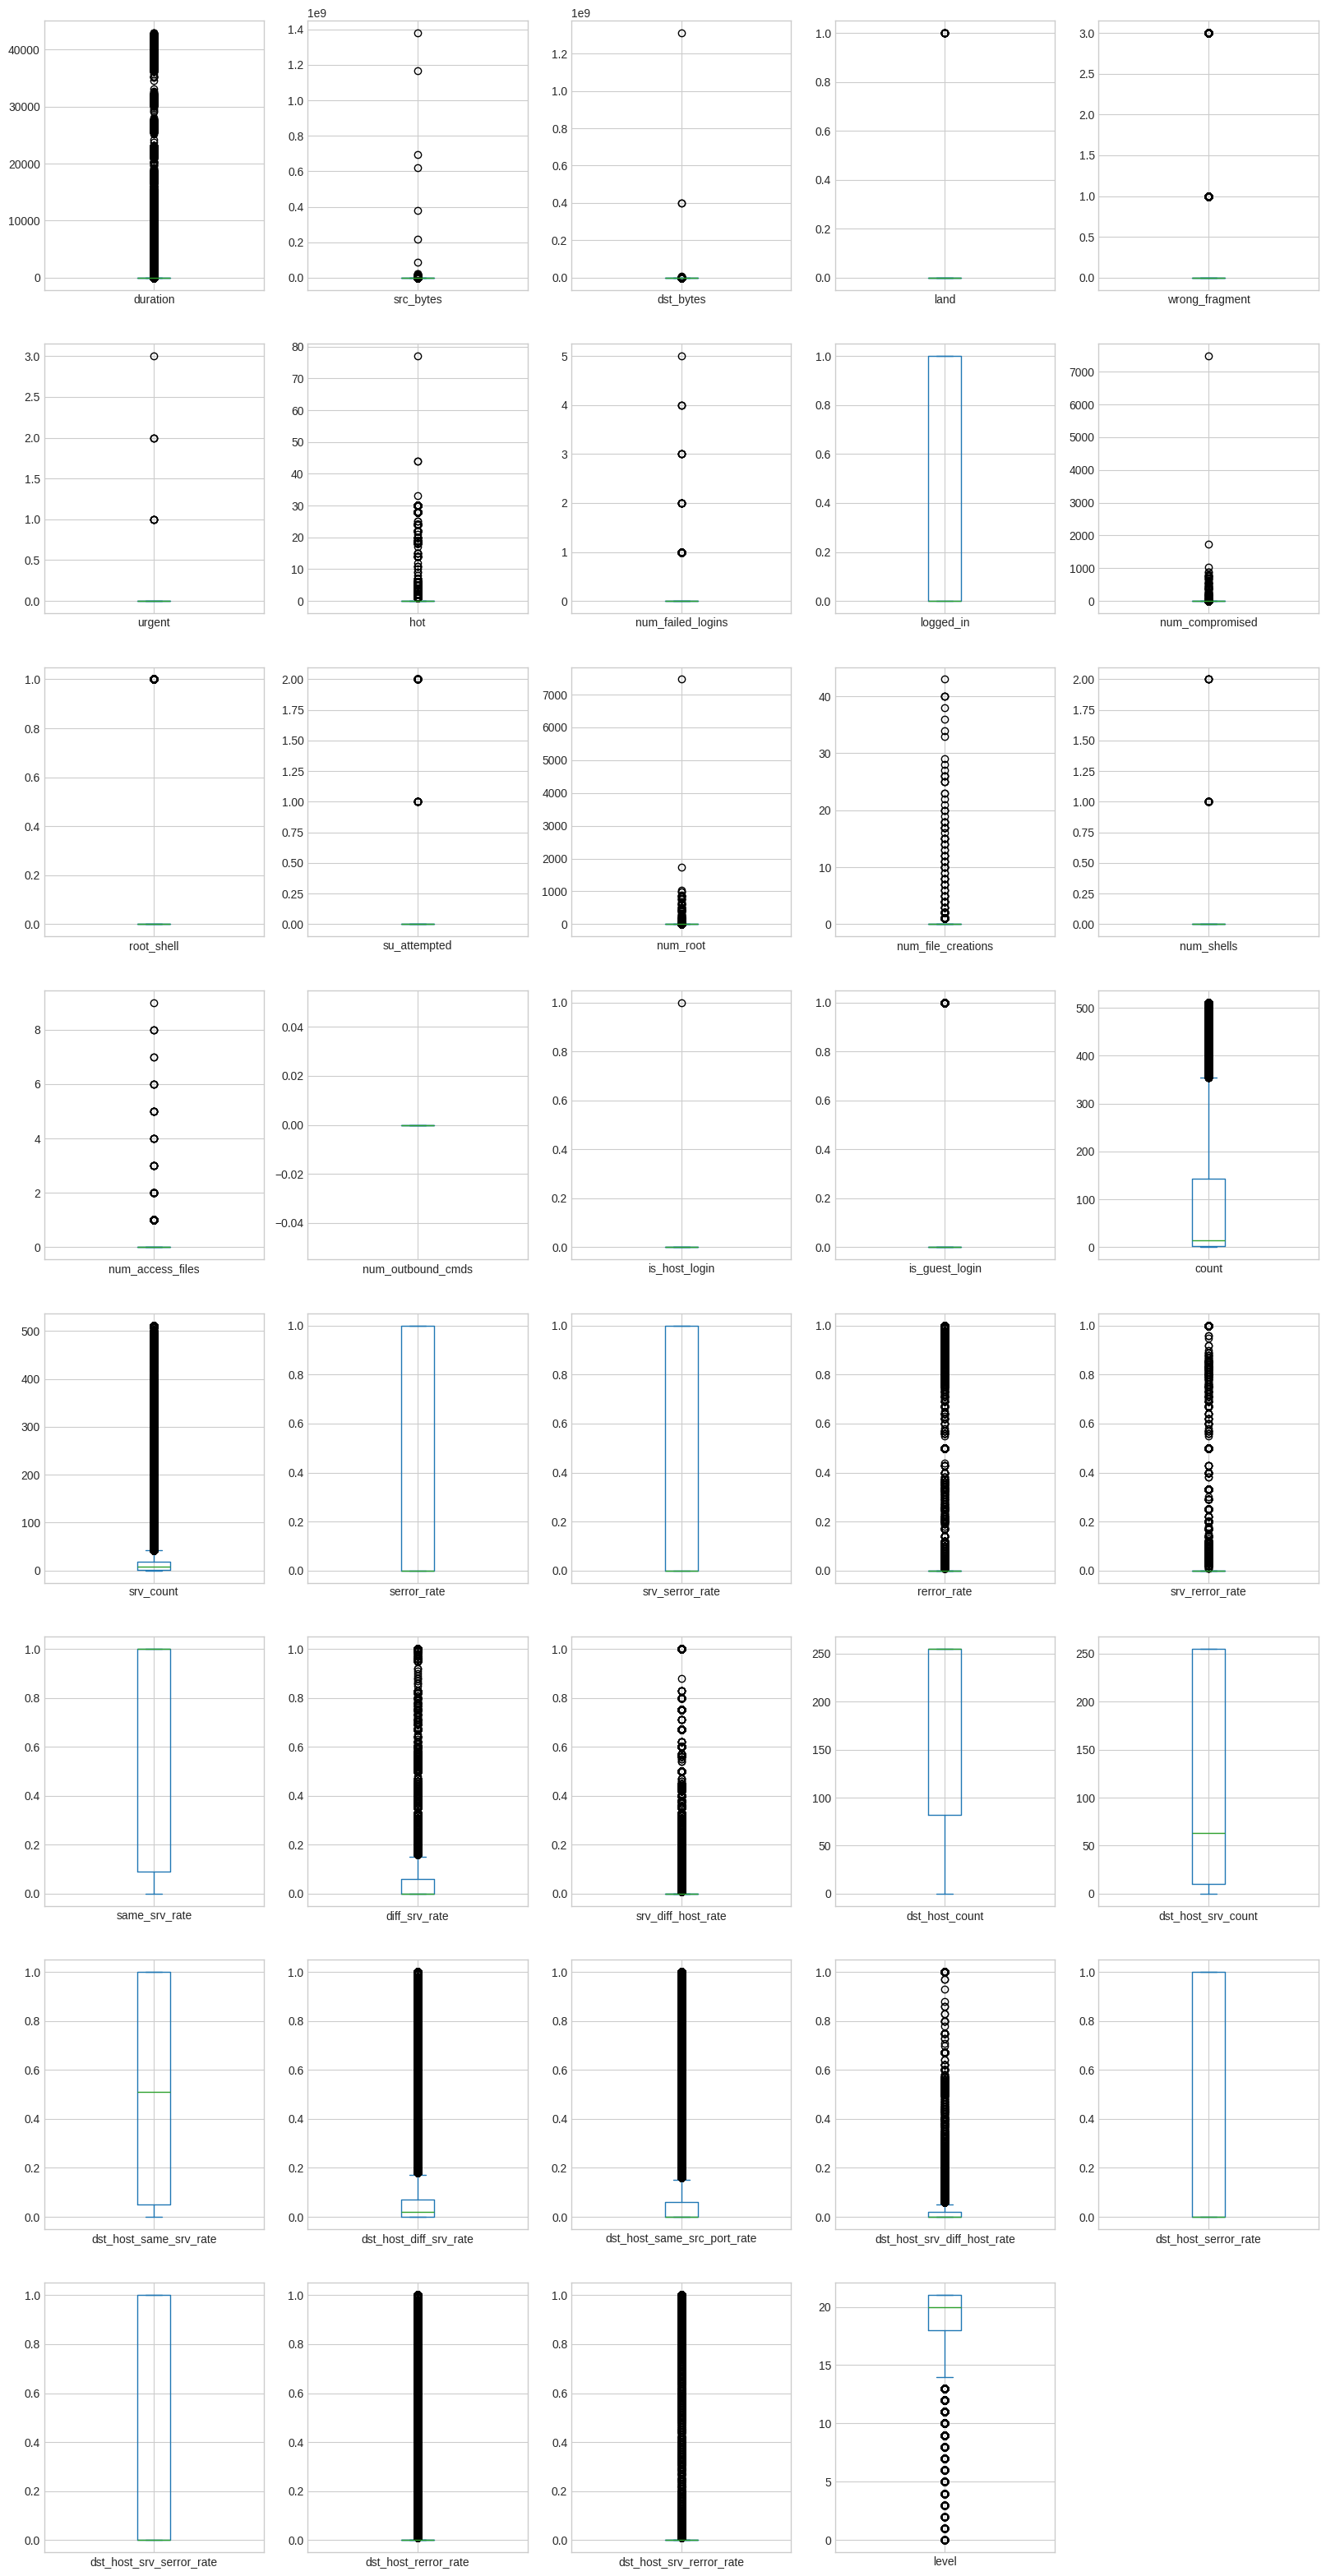

In [ ]:
plt.figure(figsize=(20, 40))
data_train.plot(kind='box', subplots=True, layout=(8, 5), figsize=(20, 40))
plt.show()

In [ ]:
data_train = data_train.drop('num_outbound_cmds', axis = 1)

# 4. Преобразование меток.

In [ ]:
data_train['anomaly_bin'] = data_train['anomaly'].apply(lambda x: 'normal' if x == 'normal' else 'anomaly')
data_test['anomaly_bin']  = data_test['anomaly'].apply(lambda x: 'normal' if x == 'normal' else 'anomaly')

In [ ]:
label_mapping = {'normal': 0, 'anomaly': 1}
data_train['anomaly'] = data_train['anomaly_bin'].map(label_mapping)
data_test['anomaly'] = data_test['anomaly_bin'].map(label_mapping)

In [ ]:
print("Train binary distribution:")
print(data_train['anomaly'].value_counts())
print("\nTest binary distribution:")
print(data_test['anomaly'].value_counts())

Train binary distribution:
anomaly
0    67343
1    58630
Name: count, dtype: int64

Test binary distribution:
anomaly
1    12833
0     9711
Name: count, dtype: int64


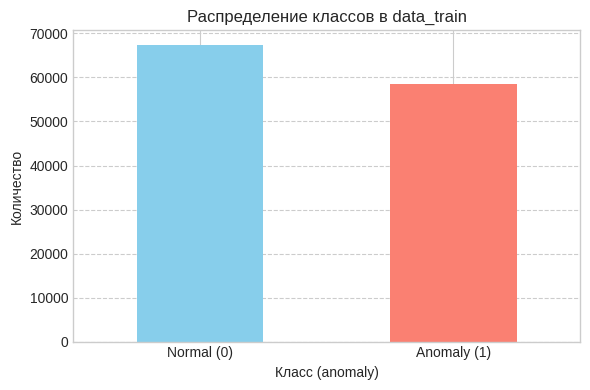

In [ ]:
data_train['anomaly'].value_counts().plot(kind='bar', figsize=(6,4), color=['skyblue', 'salmon'])
plt.title('Распределение классов в data_train')
plt.xlabel('Класс (anomaly)')
plt.ylabel('Количество')
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Anomaly (1)'], rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

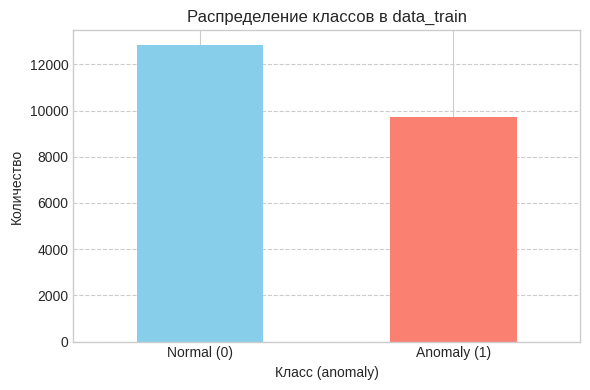

In [ ]:
data_test['anomaly'].value_counts().plot(kind='bar', figsize=(6,4), color=['skyblue', 'salmon'])
plt.title('Распределение классов в data_train')
plt.xlabel('Класс (anomaly)')
plt.ylabel('Количество')
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Anomaly (1)'], rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,anomaly,level,anomaly_bin
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.000,0.000,0.000,0.000,1.000,0.000,0.000,150,25,0.170,0.030,0.170,0.000,0.000,0.000,0.050,0.000,0,20,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.000,0.000,0.000,0.000,0.080,0.150,0.000,255,1,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,0,15,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.000,1.000,0.000,0.000,0.050,0.070,0.000,255,26,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,1,19,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,5,5,0.200,0.200,0.000,0.000,1.000,0.000,0.000,30,255,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,0,21,normal
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,30,32,0.000,0.000,0.000,0.000,1.000,0.000,0.090,255,255,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,21,normal


# 5. EDA (Exploratory Data Analysis).

In [ ]:
# EDA: распределение классов
data_train['anomaly'].value_counts(normalize=True)

,proportion
anomaly,
0,0.535
1,0.465


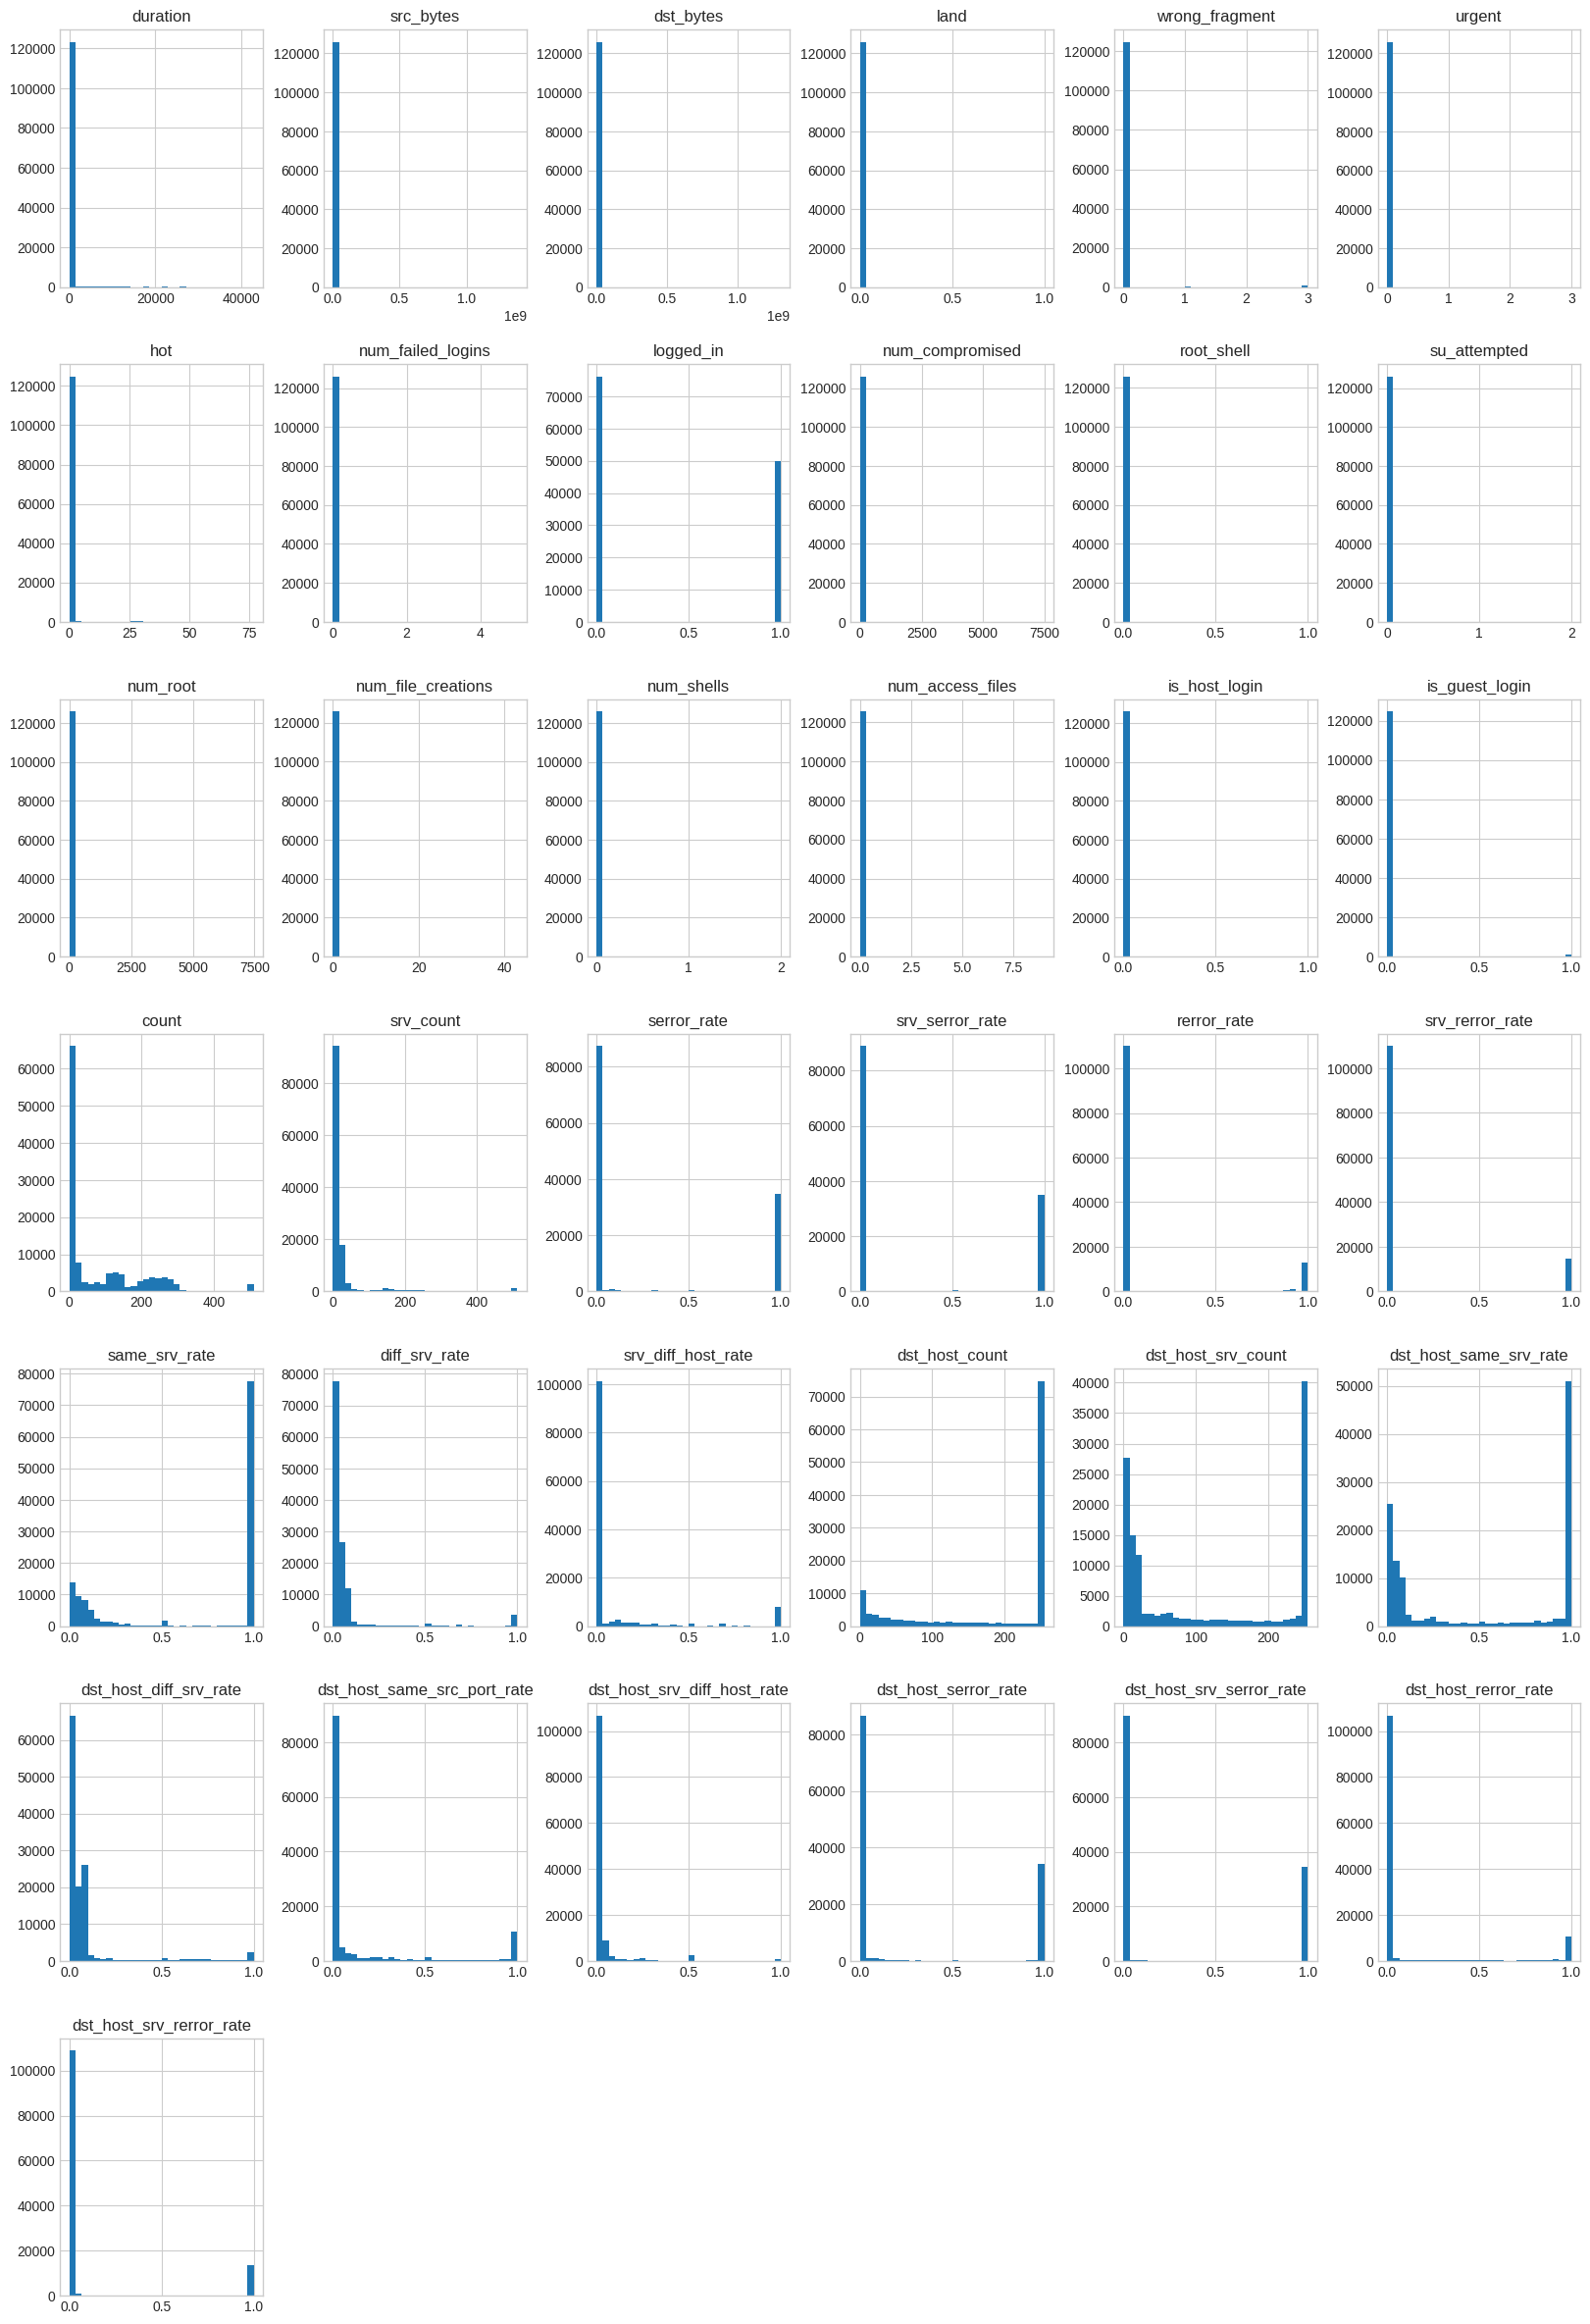

In [ ]:
# гистограммы для ключевых числовых признаков
num_features = data_train.select_dtypes(include=['int64','float64']).columns.drop(['anomaly','level'])
data_train[num_features].hist(bins=30, figsize=(20,30))
plt.show()

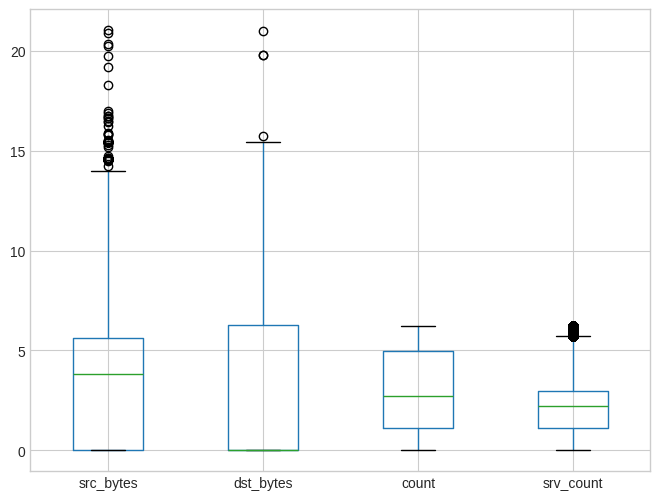

In [ ]:
# boxplot для skewed признаков
skewed = ['src_bytes','dst_bytes','count','srv_count']
data_train[skewed].apply(lambda x: np.log1p(x)).boxplot(figsize=(8,6))
plt.show()

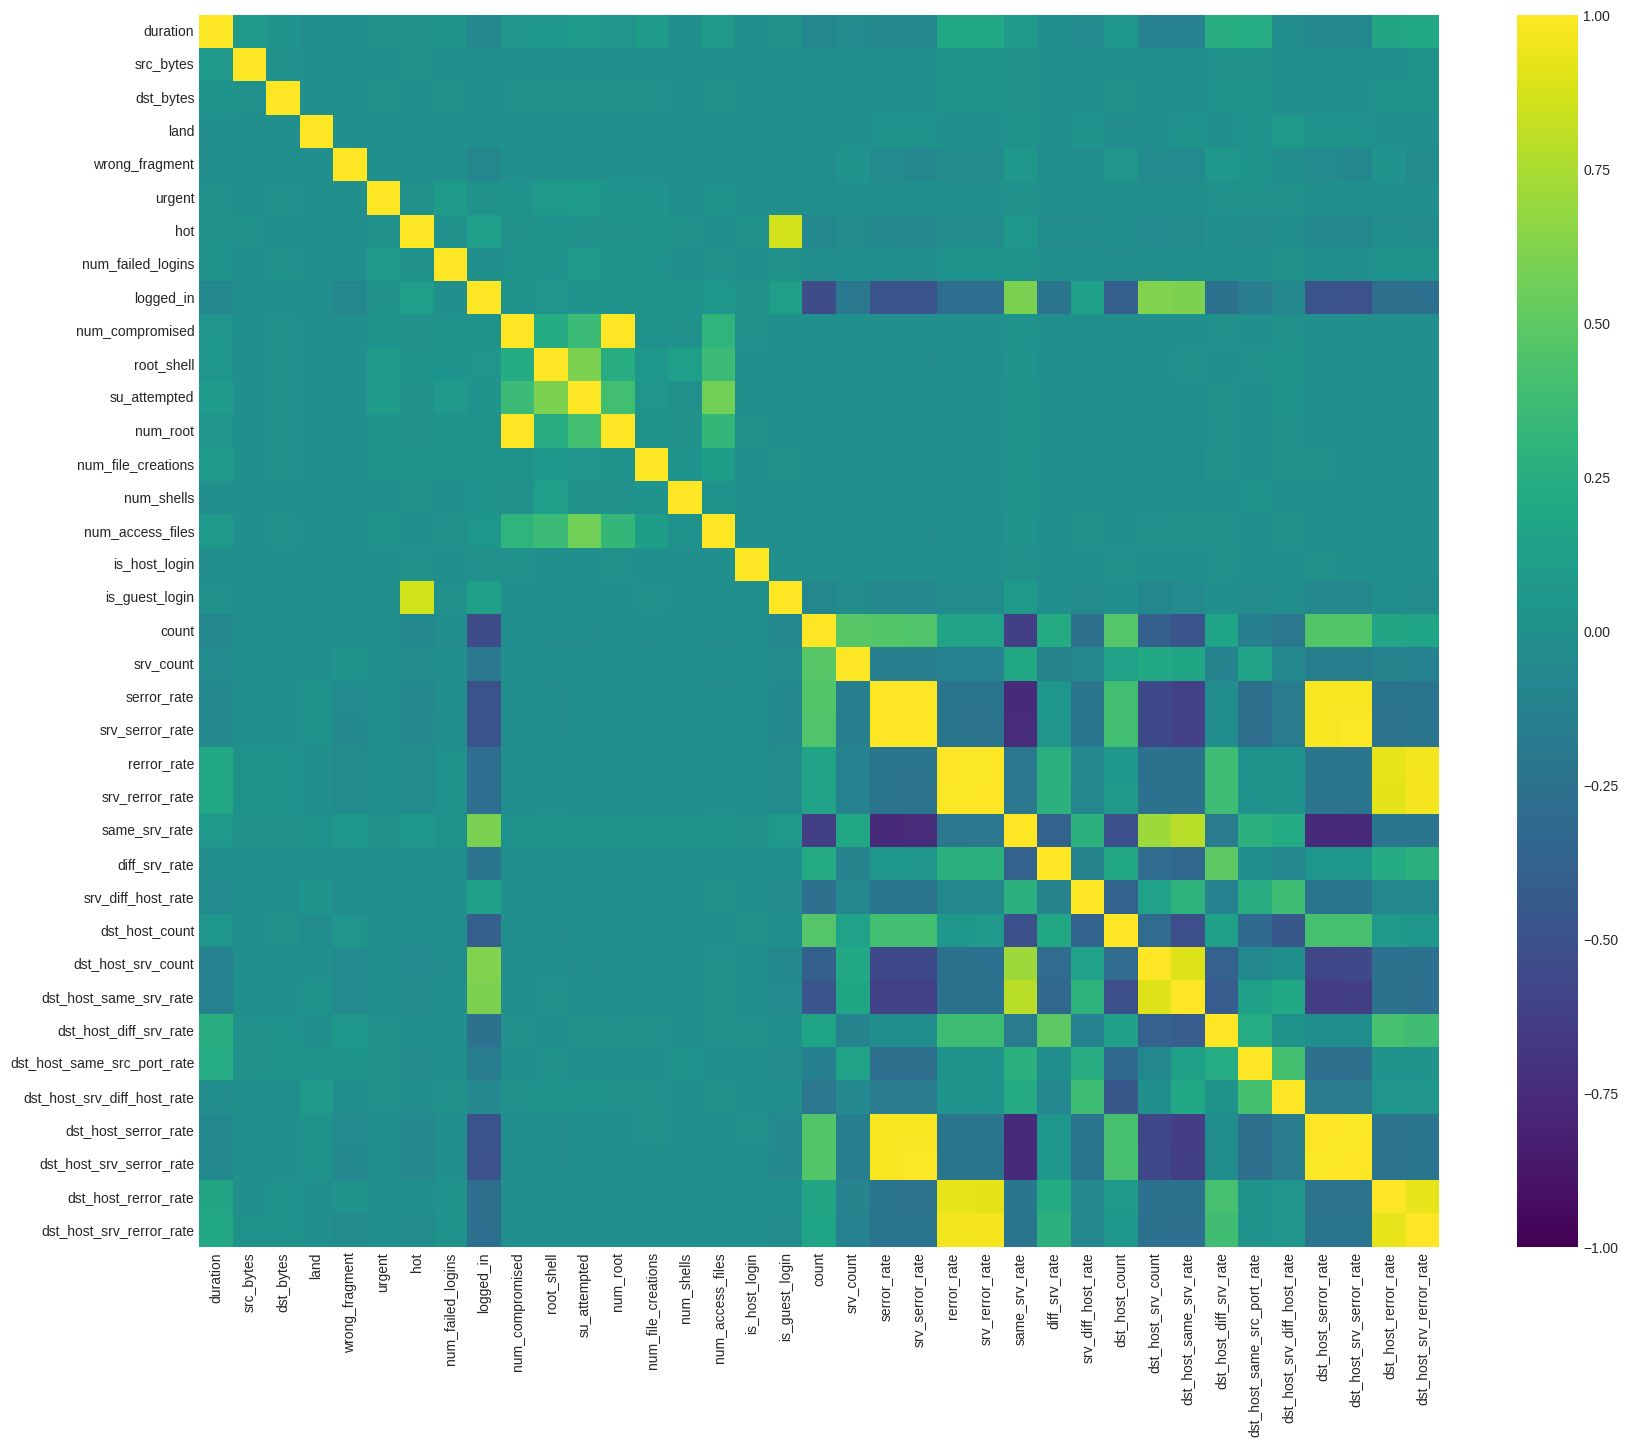

In [ ]:
# корреляционная матрица и тепловая карта
# Надо пофиксить нормально отображение с цифрами
corr = data_train[num_features].corr()
plt.figure(figsize=(20,16))
sns.heatmap(corr, cmap='viridis', vmax=1, vmin=-1, annot = True)
plt.show()

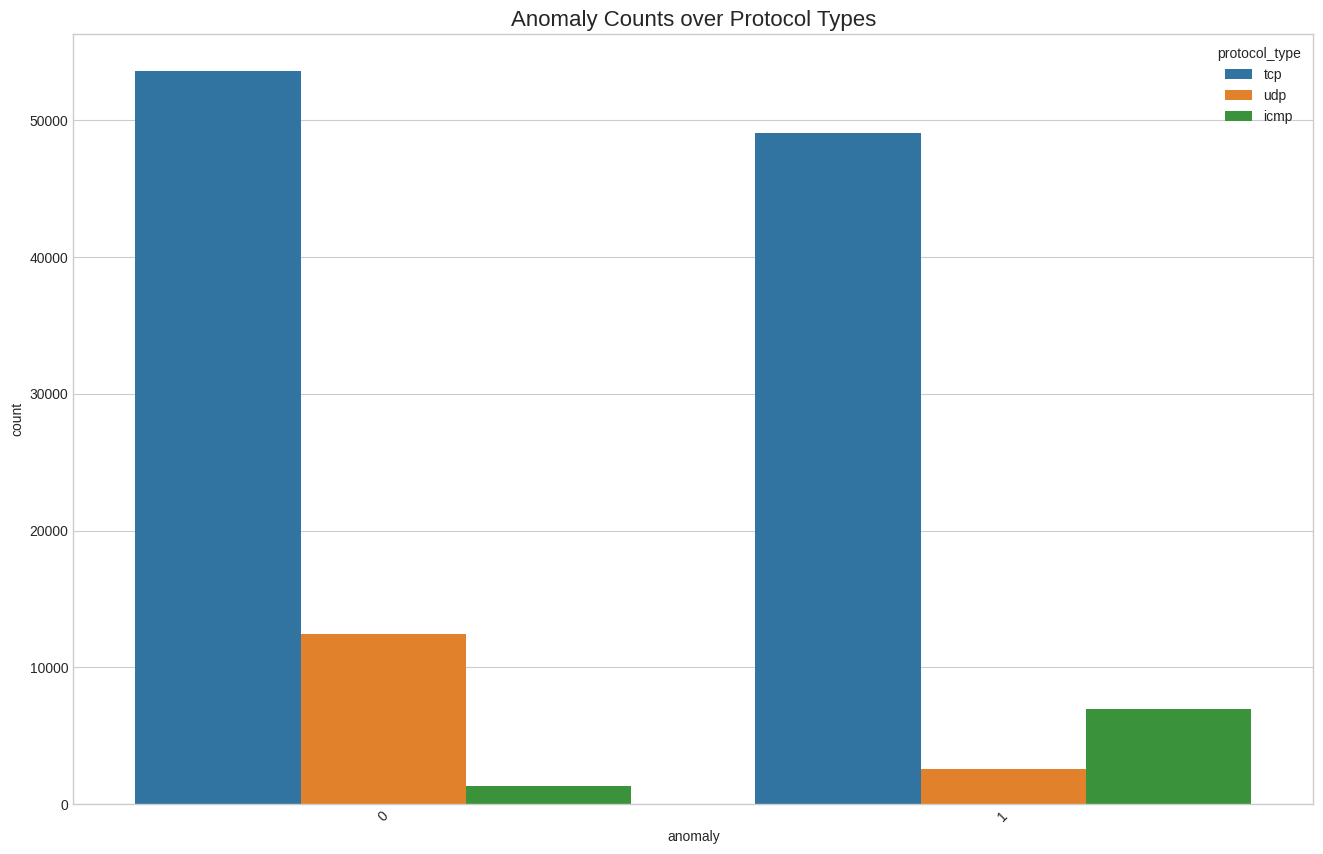

In [ ]:
plt.figure(figsize=(16,10))
sns.countplot(x='anomaly', data = data_train, hue='protocol_type')
plt.xticks(rotation=45)
plt.title('Anomaly Counts over Protocol Types',fontdict={'fontsize':16})
plt.show()

In [ ]:
# анализ категориальных признаков
for col in ['protocol_type','service','flag']:
    print(col, data_train[col].value_counts().head(10), '\n')

protocol_type protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64 

service service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64 

flag flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
Name: count, dtype: int64 



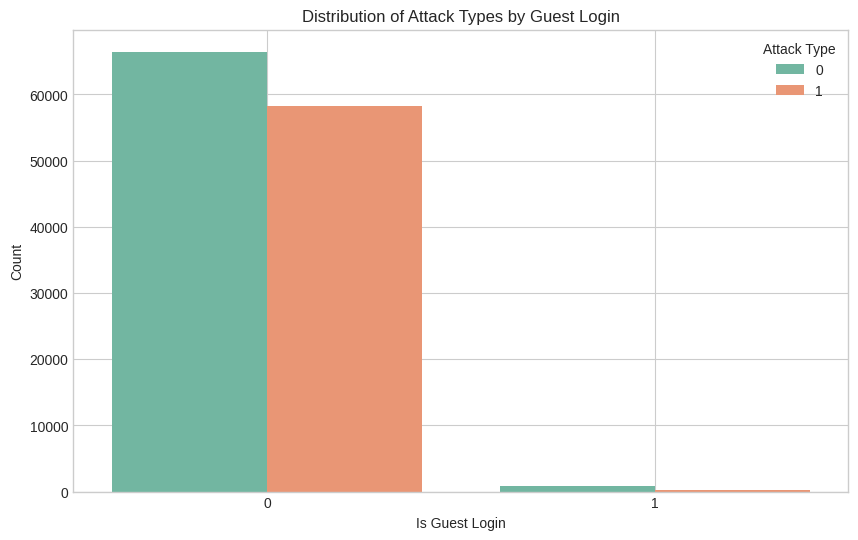

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='is_guest_login', hue='anomaly', data=data_train, palette='Set2')
plt.xlabel('Is Guest Login')
plt.ylabel('Count')
plt.title('Distribution of Attack Types by Guest Login')
plt.legend(title='Attack Type')
plt.grid(True)
plt.show()

# 6. Формирование препроцессинга

In [ ]:
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,anomaly,level,anomaly_bin
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.000,0.000,0.000,0.000,1.000,0.000,0.000,150,25,0.170,0.030,0.170,0.000,0.000,0.000,0.050,0.000,0,20,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.000,0.000,0.000,0.000,0.080,0.150,0.000,255,1,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,0,15,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.000,1.000,0.000,0.000,0.050,0.070,0.000,255,26,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,1,19,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,5,5,0.200,0.200,0.000,0.000,1.000,0.000,0.000,30,255,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,0,21,normal
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,30,32,0.000,0.000,0.000,0.000,1.000,0.000,0.090,255,255,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,21,normal


In [ ]:
cat_features = ['protocol_type', 'service', 'flag']
cat_features

['protocol_type', 'service', 'flag']

In [ ]:
num_features = [c for c in data_train.columns
                if c not in cat_features + ['anomaly', 'anomaly_bin', 'level']]
num_features

['duration',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate']

In [ ]:
# препроцессор
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num', StandardScaler(), num_features)
])

In [ ]:
# сплит внутри тренировочного набора
X = data_train.drop(['anomaly', 'anomaly_bin', 'level'], axis=1)
y = data_train['anomaly']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
# Анализ важности признаков после базового препроцессинга
X_train_processed_temp = preprocessor.fit_transform(X_train)
feature_names_processed = preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(X_train_processed_temp, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_names_processed).sort_values(ascending=False)
print(mi_series.head(40)) # Посмотрим на топ-40

num__src_bytes                     0.567
num__dst_bytes                     0.439
num__diff_srv_rate                 0.364
num__same_srv_rate                 0.360
cat__flag_SF                       0.341
num__dst_host_srv_count            0.332
num__dst_host_same_srv_rate        0.308
num__logged_in                     0.290
num__dst_host_diff_srv_rate        0.288
num__dst_host_serror_rate          0.287
num__dst_host_srv_serror_rate      0.283
num__serror_rate                   0.282
num__srv_serror_rate               0.271
num__count                         0.266
cat__flag_S0                       0.263
cat__service_http                  0.193
num__dst_host_srv_diff_host_rate   0.191
num__dst_host_count                0.140
num__dst_host_same_src_port_rate   0.132
cat__service_private               0.118
num__srv_diff_host_rate            0.101
num__srv_count                     0.066
num__dst_host_srv_rerror_rate      0.062
cat__service_domain_u              0.047
num__rerror_rate

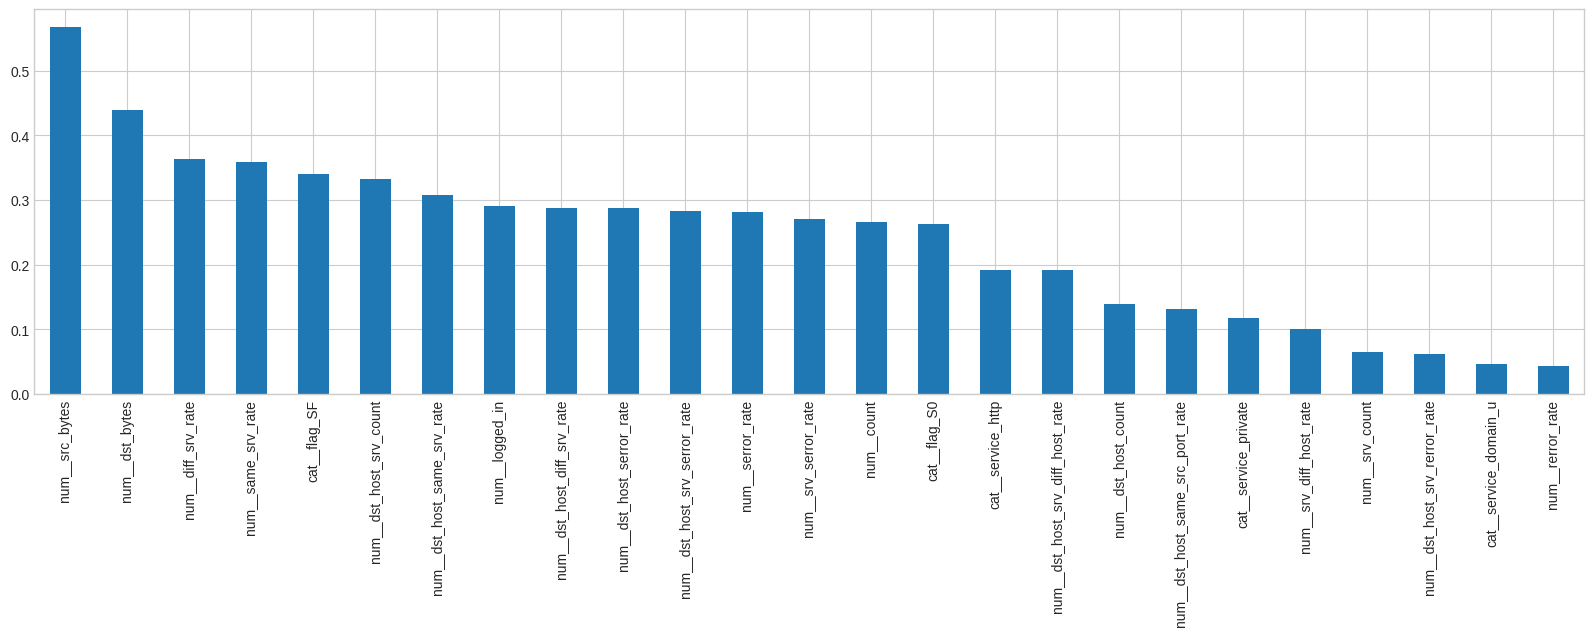

In [ ]:
mi_series.head(25).plot.bar(figsize=(20, 5))
plt.show()

# 7. Постройка моделей.

## 7.1 Логистичнская регрессия.

In [ ]:
model_lr = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid_lr = [
    {
        'clf__solver': ['liblinear'],
        'clf__C': [0.1, 1, 10, 100]
    }]

gs_lr = GridSearchCV(model_lr, param_grid_lr,
                     cv=5, scoring='roc_auc', n_jobs=-1, return_train_score=True)

start_time_lr = time.time()
gs_lr.fit(X_train, y_train)
end_time_lr = time.time()
training_time_lr = end_time_lr - start_time_lr
print(f"Лучший ROC AUC на кросс-валидации: {gs_lr.best_score_:.4f}")
print(f"Лучшие параметры: {gs_lr.best_params_}")
print(f"Общее время подбора гиперпараметров (GridSearchCV): {training_time_lr:.2f} сек")

Лучший ROC AUC на кросс-валидации: 0.9965
Лучшие параметры: {'clf__C': 10, 'clf__solver': 'liblinear'}
Общее время подбора гиперпараметров (GridSearchCV): 145.32 сек


In [ ]:
# Оценка лучшей модели на валидационном наборе
best_lr_model = gs_lr.best_estimator_
y_val_pred_lr = best_lr_model.predict(X_val)
y_val_proba_lr = best_lr_model.predict_proba(X_val)[:, 1]
print(roc_auc_score(y_val, y_val_proba_lr))

0.9964080536823005


In [ ]:
print(classification_report(y_val, y_val_pred_lr, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       0.97      0.98      0.97     13469
 Anomaly (1)       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195



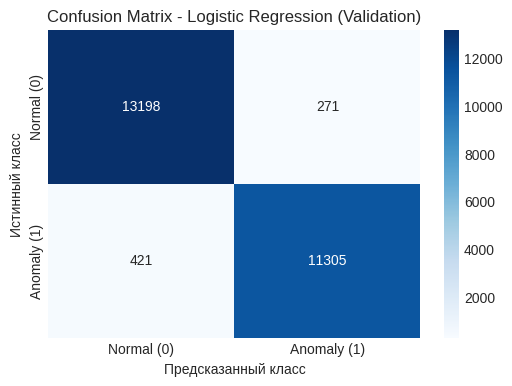

In [ ]:
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix - Logistic Regression (Validation)')
plt.show()

In [ ]:
best_lr_model

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   '...eations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count',
                                                   'dst_host_same_srv_rate', ...])])),
                ('clf',
                 LogisticRegression(C=10, max_iter=1000, solver='liblinear'))])

In [ ]:
val_roc_auc_lr = roc_auc_score(y_val, y_val_proba_lr)
val_f1_anomaly_lr = f1_score(y_val, y_val_pred_lr, pos_label=1)
results_summary['LogisticRegression'] = {
    'best_cv_roc_auc': gs_lr.best_score_,
    'best_params': gs_lr.best_params_,
    'val_roc_auc': val_roc_auc_lr,
    'val_f1_anomaly': val_f1_anomaly_lr,
    'training_time_total_gs': training_time_lr, # Это теперь время RandomizedSearch
    #'training_time_fold_mean': mean_fit_time_best_lr,
    'estimator': best_lr_model
}

In [ ]:
models_dir = "saved_models"
os.makedirs(models_dir, exist_ok=True)

model_filename_lr = os.path.join(models_dir, "best_logistic_regression_pipeline.joblib")
joblib.dump(best_lr_model, model_filename_lr)

['saved_models/best_logistic_regression_pipeline.joblib']

## 7.2 Наивный Байес (GaussianNB).

In [ ]:
model_nb = Pipeline([
    ('preproc', preprocessor),
    ('clf', GaussianNB())
])

param_grid_nb = {
    'clf__var_smoothing': np.logspace(-9, -2, 8)
}

gs_nb = GridSearchCV(model_nb, param_grid_nb, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='roc_auc',n_jobs=-1,return_train_score=True)

start_time_nb = time.time()
gs_nb.fit(X_train, y_train)
end_time_nb = time.time()
training_time_nb = end_time_nb - start_time_nb
print(f"Лучший ROC AUC на кросс-валидации: {gs_nb.best_score_:.4f}")
print(f"Лучшие параметры: {gs_nb.best_params_}")
print(f"Общее время подбора гиперпараметров (GridSearchCV): {training_time_nb:.2f} сек")

Лучший ROC AUC на кросс-валидации: 0.9801
Лучшие параметры: {'clf__var_smoothing': np.float64(0.0001)}
Общее время подбора гиперпараметров (GridSearchCV): 9.94 сек


In [ ]:
best_nb_model = gs_nb.best_estimator_
y_val_pred_nb = best_nb_model.predict(X_val)
y_val_proba_nb = best_nb_model.predict_proba(X_val)[:, 1]
print(roc_auc_score(y_val, y_val_proba_nb))

0.9790792774007164


In [ ]:
print(classification_report(y_val, y_val_pred_nb, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       0.89      0.98      0.93     13469
 Anomaly (1)       0.97      0.87      0.92     11726

    accuracy                           0.93     25195
   macro avg       0.93      0.92      0.93     25195
weighted avg       0.93      0.93      0.93     25195



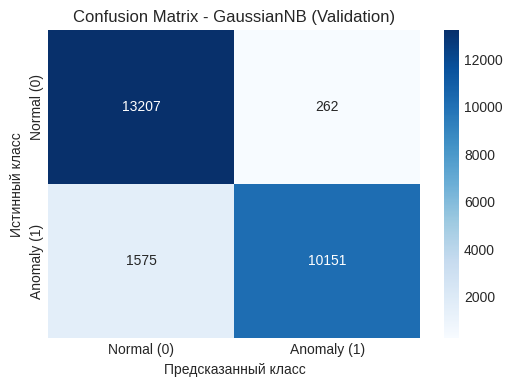

In [ ]:
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix - GaussianNB (Validation)')
plt.show()

In [ ]:
best_nb_model

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count',
                                                   'dst_host_same_srv_rate', ...])])),
                ('clf', GaussianNB(var_smoothing=np.float64(0.0001)))])

In [ ]:
val_roc_auc_nb = roc_auc_score(y_val, y_val_proba_nb)
val_f1_anomaly_nb = f1_score(y_val, y_val_pred_nb, pos_label=1)
results_summary['GaussianNB'] = {
    'best_cv_roc_auc': gs_nb.best_score_,
    'best_params': gs_nb.best_params_,
    'val_roc_auc': val_roc_auc_nb,
    'val_f1_anomaly': val_f1_anomaly_nb,
    'training_time_total_gs': training_time_nb,
    #'training_time_fold_mean': mean_fit_time_best_nb,
    'estimator': best_nb_model
}

In [ ]:
model_filename_nb = os.path.join(models_dir, "best_gaussian_nb_pipeline.joblib")
joblib.dump(best_nb_model, model_filename_nb)

['saved_models/best_gaussian_nb_pipeline.joblib']

## 7.3 Метод опорных векторов (SVM).

In [ ]:
model_sgd = Pipeline([
    ('preproc', preprocessor),
    ('clf', SGDClassifier(max_iter=1000, tol=1e-3, random_state=42, early_stopping=True, n_iter_no_change=5, validation_fraction=0.1))
])

param_grid_sgd = {
    'clf__alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'clf__loss': ['hinge', 'log_loss'],
    'clf__penalty': ['l2', 'l1', 'elasticnet']
}

gs_sgd = GridSearchCV(model_sgd, param_grid_sgd, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',n_jobs=-1,return_train_score=True
)

start_time_sgd = time.time()
gs_sgd.fit(X_train, y_train)
end_time_sgd = time.time()
training_time_sgd = end_time_sgd - start_time_sgd
print(f"Лучший ROC AUC на кросс-валидации: {gs_sgd.best_score_:.4f}")
print(f"Лучшие параметры: {gs_sgd.best_params_}")
print(f"Общее время подбора гиперпараметров (GridSearchCV): {training_time_sgd:.2f} сек")

Лучший ROC AUC на кросс-валидации: 0.9955
Лучшие параметры: {'clf__alpha': 0.001, 'clf__loss': 'hinge', 'clf__penalty': 'l2'}
Общее время подбора гиперпараметров (GridSearchCV): 17.45 сек


In [ ]:
best_sgd_model = gs_sgd.best_estimator_
y_val_pred_sgd = best_sgd_model.predict(X_val)
# Для SGDClassifier с loss='hinge' (SVM) нет метода predict_proba по умолчанию.


In [ ]:
if hasattr(best_sgd_model.named_steps['clf'], "predict_proba"): # Проверяем у классификатора внутри пайплайна
    y_val_proba_sgd = best_sgd_model.predict_proba(X_val)[:, 1]
    val_roc_auc_sgd = roc_auc_score(y_val, y_val_proba_sgd)
elif hasattr(best_sgd_model.named_steps['clf'], "decision_function"):
    y_val_decision_sgd = best_sgd_model.decision_function(X_val)
    val_roc_auc_sgd = roc_auc_score(y_val, y_val_decision_sgd) # ROC AUC можно считать по decision_function
else:
    val_roc_auc_sgd = float('nan') # Не удалось получить вероятности или скоры

val_f1_anomaly_sgd = f1_score(y_val, y_val_pred_sgd, pos_label=1)

In [ ]:
print(f"ROC AUC: {val_roc_auc_sgd:.4f}")

ROC AUC: 0.9956


In [ ]:
print(classification_report(y_val, y_val_pred_sgd, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       0.97      0.98      0.97     13469
 Anomaly (1)       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195



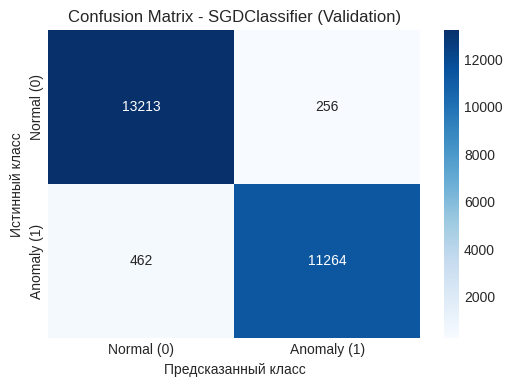

In [ ]:
cm_sgd = confusion_matrix(y_val, y_val_pred_sgd)
plt.figure(figsize=(6,4))
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix - SGDClassifier (Validation)')
plt.show()

In [ ]:
best_sgd_model

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   '...ns',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count',
                                                   'dst_host_same_srv_rate', ...])])),
                ('clf',
                 SGDClassifier(alpha=0.001, early_stopping=True,
                               random_state=42))])

In [ ]:
results_summary['SGDClassifier'] = {
    'best_cv_roc_auc': gs_sgd.best_score_,
    'best_params': gs_sgd.best_params_,
    'val_roc_auc': val_roc_auc_sgd,
    'val_f1_anomaly': val_f1_anomaly_sgd,
    'training_time_total_gs': training_time_sgd,
    #'training_time_fold_mean': mean_fit_time_best_sgd,
    'estimator': best_sgd_model
}

In [ ]:
model_filename_sgd = os.path.join(models_dir, "best_sgd_classifier_pipeline.joblib")
joblib.dump(best_sgd_model, model_filename_sgd)

['saved_models/best_sgd_classifier_pipeline.joblib']

## 7.4 Случайный лес (Random Forest).

In [ ]:
model_rf = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2]
}

gs_rf = GridSearchCV(model_rf, param_grid_rf,cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1,return_train_score=True
)

start_time_rf = time.time()
gs_rf.fit(X_train, y_train)
end_time_rf = time.time()
training_time_rf = end_time_rf - start_time_rf
print(f"Лучший ROC AUC на кросс-валидации: {gs_rf.best_score_:.4f}")
print(f"Лучшие параметры: {gs_rf.best_params_}")
print(f"Общее время подбора гиперпараметров (GridSearchCV): {training_time_rf:.2f} сек")

Лучший ROC AUC на кросс-валидации: 1.0000
Лучшие параметры: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Общее время подбора гиперпараметров (GridSearchCV): 89.07 сек


In [ ]:
best_rf_model = gs_rf.best_estimator_
y_val_pred_rf = best_rf_model.predict(X_val)
y_val_proba_rf = best_rf_model.predict_proba(X_val)[:, 1]
print(roc_auc_score(y_val, y_val_proba_rf))

0.9999942508901654


In [ ]:
print(classification_report(y_val, y_val_pred_rf, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     13469
 Anomaly (1)       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



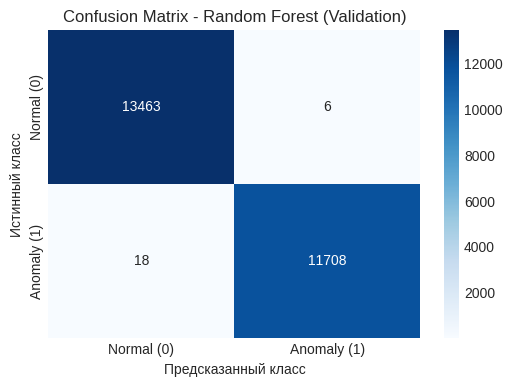

In [ ]:
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix - Random Forest (Validation)')
plt.show()

In [ ]:
best_rf_model

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   '...tions',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count',
                                                   'dst_host_same_srv_rate', ...])])),
                ('clf',
                 RandomForestClassifier(min_samples_split=5, random_state=42))])

In [ ]:
val_roc_auc_rf = roc_auc_score(y_val, y_val_proba_rf)
val_f1_anomaly_rf = f1_score(y_val, y_val_pred_rf, pos_label=1)
results_summary['RandomForest'] = {
    'best_cv_roc_auc': gs_rf.best_score_,
    'best_params': gs_rf.best_params_,
    'val_roc_auc': val_roc_auc_rf,
    'val_f1_anomaly': val_f1_anomaly_rf,
    'training_time_total_gs': training_time_rf,
    #'training_time_fold_mean': mean_fit_time_best_rf,
    'estimator': best_rf_model
}

In [ ]:
model_filename_rf = os.path.join(models_dir, "best_random_forest_pipeline.joblib")
joblib.dump(best_rf_model, model_filename_rf)

['saved_models/best_random_forest_pipeline.joblib']

## 7.5 XGBoost.

In [ ]:
model_xgb = Pipeline([
    ('preproc', preprocessor),
    ('clf', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,))
])


param_grid_xgb = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 1.0],
    'clf__colsample_bytree': [0.7, 1.0]
}

gs_xgb = GridSearchCV(model_xgb, param_grid_xgb,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, return_train_score=True
)

start_time_xgb = time.time()
gs_xgb.fit(X_train, y_train)
end_time_xgb = time.time()
training_time_xgb = end_time_xgb - start_time_xgb
print(f"Лучший ROC AUC на кросс-валидации: {gs_xgb.best_score_:.4f}")
print(f"Лучшие параметры: {gs_xgb.best_params_}")
print(f"Общее время подбора гиперпараметров (GridSearchCV): {training_time_xgb:.2f} сек")

Лучший ROC AUC на кросс-валидации: 1.0000
Лучшие параметры: {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.2, 'clf__max_depth': 7, 'clf__n_estimators': 100, 'clf__subsample': 1.0}
Общее время подбора гиперпараметров (GridSearchCV): 115.46 сек


In [ ]:
best_xgb_model = gs_xgb.best_estimator_
y_val_pred_xgb = best_xgb_model.predict(X_val)
y_val_proba_xgb = best_xgb_model.predict_proba(X_val)[:, 1]
print(roc_auc_score(y_val, y_val_proba_xgb))

0.9999923260780622


In [ ]:
print(classification_report(y_val, y_val_pred_xgb, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     13469
 Anomaly (1)       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



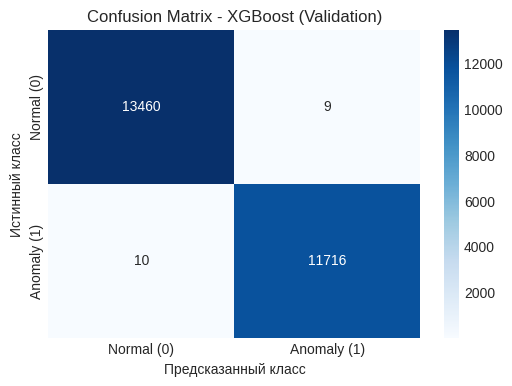

In [ ]:
cm_xgb = confusion_matrix(y_val, y_val_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix - XGBoost (Validation)')
plt.show()

In [ ]:
best_xgb_model

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.2,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
val_roc_auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)
val_f1_anomaly_xgb = f1_score(y_val, y_val_pred_xgb, pos_label=1)
results_summary['XGBoost'] = {
    'best_cv_roc_auc': gs_xgb.best_score_,
    'best_params': gs_xgb.best_params_,
    'val_roc_auc': val_roc_auc_xgb,
    'val_f1_anomaly': val_f1_anomaly_xgb,
    'training_time_total_gs': training_time_xgb,
    #'training_time_fold_mean': mean_fit_time_best_xgb,
    'estimator': best_xgb_model
}

In [ ]:
model_filename_xgb = os.path.join(models_dir, "best_xgboost_pipeline.joblib")
joblib.dump(best_xgb_model, model_filename_xgb)

['saved_models/best_xgboost_pipeline.joblib']

## 7.6 Isolation Forest.

In [ ]:
# Для Isolation Forest мы будем обучать классификатор отдельно после препроцессинга,
# так как его нужно обучать на "нормальных" данных.
# Но препроцессор нам все равно нужен для X_val и X_test.
# Сначала обучим препроцессор на всем X_train, чтобы он был готов
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)

In [ ]:
X_train_normal_processed = X_train_processed[y_train == 0]

In [ ]:
contamination_value = float(y_train.value_counts(normalize=True).get(1, 0.1)) # Доля класса 1, или 0.1 по умолчанию
if contamination_value == 0: # Если в y_train только нормальные (маловероятно для общего y_train)
    contamination_value = 0.05

iso_forest = IsolationForest(
    n_estimators=150,
    contamination=contamination_value, # Это значение contamination будет влиять на predict
    random_state=42,
    n_jobs=-1,
    max_samples='auto'
)
print(f"Обучение Isolation Forest на {X_train_normal_processed.shape[0]} нормальных сэмплах...")
print(f"Используемое значение contamination: {contamination_value:.4f}")

start_time_if = time.time()
iso_forest.fit(X_train_normal_processed) # Обучаем только на нормальных данных
end_time_if = time.time()
training_time_if = end_time_if - start_time_if
print(f"Время обучения Isolation Forest: {training_time_if:.2f} сек")


Обучение Isolation Forest на 53874 нормальных сэмплах...
Используемое значение contamination: 0.4654
Время обучения Isolation Forest: 0.69 сек


In [ ]:
# Предсказания на валидационном наборе
# predict вернет 1 для нормальных (inliers) и -1 для аномалий (outliers)
y_val_pred_if_raw = iso_forest.predict(X_val_processed)
# Преобразуем в 0 (normal) и 1 (anomaly)
y_val_pred_if = np.array([0 if x == 1 else 1 for x in y_val_pred_if_raw])

In [ ]:
# Оценка аномальности (чем меньше, тем более аномально)
y_val_scores_if = iso_forest.decision_function(X_val_processed)
# Для ROC AUC нам нужны скоры, где более высокое значение = аномалия, поэтому инвертируем
y_val_proba_if_for_roc = -y_val_scores_if

In [ ]:
print(roc_auc_score(y_val, y_val_proba_if_for_roc))

0.9803994895600914


In [ ]:
print(classification_report(y_val, y_val_pred_if, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       1.00      0.53      0.70     13469
 Anomaly (1)       0.65      1.00      0.79     11726

    accuracy                           0.75     25195
   macro avg       0.83      0.77      0.74     25195
weighted avg       0.84      0.75      0.74     25195



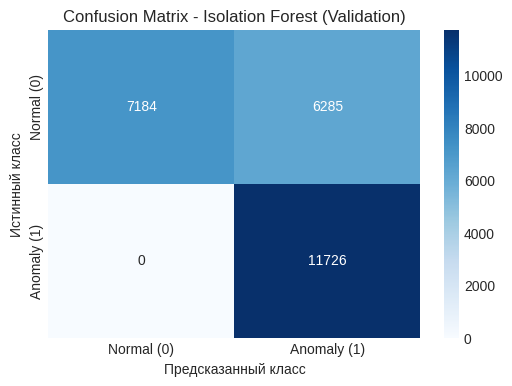

In [ ]:
cm_if = confusion_matrix(y_val, y_val_pred_if)
plt.figure(figsize=(6,4))
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix - Isolation Forest (Validation)')
plt.show()

In [ ]:
results_summary['IsolationForest'] = {
    'best_cv_roc_auc': None, # Не применимо напрямую
    'best_params': {'n_estimators': 100, 'contamination': contamination_value},
    #'val_roc_auc': val_roc_auc_if,
    #'val_f1_anomaly': val_f1_anomaly_if,
    'training_time_total_gs': training_time_if, # Время одного fit
    'training_time_fold_mean': training_time_if, # Время одного fit
    'estimator': iso_forest # Сохраняем обученный IsolationForest (не пайплайн, т.к. препроцессинг делали отдельно)
                           # Если нужен пайплайн, его можно собрать: Pipeline([('preproc', preprocessor), ('clf', iso_forest)])
                           # но тогда fit этого пайплайна нужно делать на X_train_normal

}

## 7.7 Автоэнкодер.

In [ ]:
# Кастомный callback для вывода логов каждые N эпох
class NBatchLogger(Callback):
    def __init__(self, display_freq=10):
        super(NBatchLogger, self).__init__()
        self.display_freq = display_freq
        self.epoch_count = 0

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_count +=1
        if self.epoch_count % self.display_freq == 0:
            logs = logs or {}
            print(f"Epoch {self.epoch_count}/{self.params['epochs']} - "
                  f"loss: {logs.get('loss'):.4f} - "
                  f"val_loss: {logs.get('val_loss'):.4f}")

In [ ]:
input_dim_ae = X_train_normal_processed.shape[1]

inp_ae = Input(shape=(input_dim_ae,))
enc_ae = Dense(64, activation='relu')(inp_ae)
enc_ae = Dense(32, activation='relu')(enc_ae)
dec_ae = Dense(64, activation='relu')(enc_ae)
out_ae = Dense(input_dim_ae, activation='linear')(dec_ae)
autoencoder = Model(inp_ae, out_ae)
autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
early_stopping_ae = EarlyStopping(monitor='val_loss', patience=15,
                                  restore_best_weights=True, verbose=1)
log_callback = NBatchLogger(display_freq=10)

In [ ]:
start_time_ae_train = time.time()
history_ae = autoencoder.fit(
    X_train_normal_processed, X_train_normal_processed,
    epochs=100, # Увеличили количество эпох
    batch_size=256,
    shuffle=True,
    validation_split=0.1,
    callbacks=[early_stopping_ae, log_callback], # Добавили наш callback
    verbose=0 # Отключаем стандартный вывод Keras, так как у нас свой callback
)
end_time_ae_train = time.time()
training_time_ae = end_time_ae_train - start_time_ae_train
print(f"Время обучения автоэнкодера: {training_time_ae:.2f} сек")

Epoch 10/200 - loss: 0.0194 - val_loss: 0.0126
Epoch 20/200 - loss: 0.0106 - val_loss: 0.0099
Epoch 30/200 - loss: 0.0073 - val_loss: 0.0106
Epoch 40/200 - loss: 0.0094 - val_loss: 0.0123
Epoch 50/200 - loss: 0.0079 - val_loss: 0.0099
Epoch 60/200 - loss: 0.0073 - val_loss: 0.0098
Epoch 70/200 - loss: 0.0042 - val_loss: 0.0073
Epoch 80/200 - loss: 0.0053 - val_loss: 0.0089
Epoch 90/200 - loss: 0.0053 - val_loss: 0.0106
Epoch 96: early stopping
Restoring model weights from the end of the best epoch: 81.
Время обучения автоэнкодера: 54.01 сек


In [ ]:
# Определение порога
reconstructions_train_norm = autoencoder.predict(X_train_normal_processed, verbose=0)
mse_train_norm = np.mean(np.power(X_train_normal_processed - reconstructions_train_norm, 2), axis=1)
threshold_ae = np.percentile(mse_train_norm, 95) # 95-й перцентиль
print(f"Порог ошибки реконструкции: {threshold_ae:.4f}")

Порог ошибки реконструкции: 0.0076


In [ ]:
# Оценка на валидационном наборе
reconstructions_val = autoencoder.predict(X_val_processed, verbose=0)
mse_val = np.mean(np.power(X_val_processed - reconstructions_val, 2), axis=1)
y_val_pred_ae = (mse_val > threshold_ae).astype(int)

# Метрики
val_roc_auc_ae = roc_auc_score(y_val, mse_val)
val_f1_anomaly_ae = f1_score(y_val, y_val_pred_ae, pos_label=1)

print("\n--- Оценка на валидационном наборе (X_val, y_val) ---")
print(f"ROC AUC (по MSE): {val_roc_auc_ae:.4f}")
print(f"F1-score (аномалия, по порогу): {val_f1_anomaly_ae:.4f}")
print("\nClassification Report (по порогу):")
print(classification_report(y_val, y_val_pred_ae, target_names=['Normal (0)', 'Anomaly (1)']))


--- Оценка на валидационном наборе (X_val, y_val) ---
ROC AUC (по MSE): 0.9863
F1-score (аномалия, по порогу): 0.9189

Classification Report (по порогу):
              precision    recall  f1-score   support

  Normal (0)       0.92      0.95      0.93     13469
 Anomaly (1)       0.94      0.90      0.92     11726

    accuracy                           0.93     25195
   macro avg       0.93      0.92      0.93     25195
weighted avg       0.93      0.93      0.93     25195



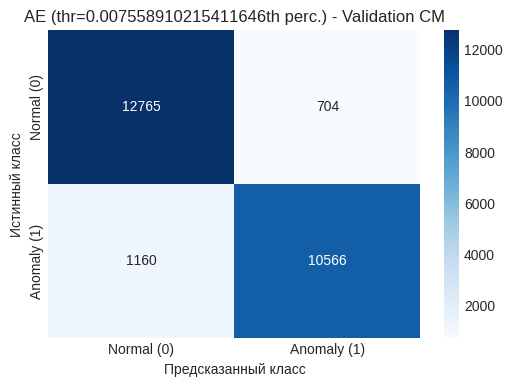

In [ ]:
cm_ae = confusion_matrix(y_val, y_val_pred_ae)
plt.figure(figsize=(6,4))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal (0)', 'Anomaly (1)'],
                yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'AE (thr={threshold_ae}th perc.) - Validation CM')
plt.show()

In [ ]:
    if 'results_summary' not in globals(): results_summary = {}
    epochs_trained_ae = early_stopping_ae.stopped_epoch if early_stopping_ae.stopped_epoch > 0 else 200
    results_summary['Autoencoder'] = {
        'best_params': {'architecture': '64-32-64', 'threshold_percentile': threshold_ae, 'epochs_trained': epochs_trained_ae},
        'val_roc_auc': val_roc_auc_ae,
        'val_f1_anomaly': val_f1_anomaly_ae,
        'training_time_total_gs': training_time_ae,
        'estimator': autoencoder # Сохраняем саму Keras модель
    }

In [ ]:
model_filename_ae = os.path.join(models_dir, "autoencoder_model.keras")

## 7.8 Полносвязная нейронная сеть (Multi-Layer Perceptron - MLP).

In [ ]:
input_dim_mlp = X_train_processed.shape[1]

mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim_mlp,)),
    Dropout(0.3), # Слой для регуляризации, помогает предотвратить переобучение
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Выходной слой для бинарной классификации
])

mlp_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]) # Добавим AUC как метрику

mlp_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping_mlp = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True, verbose=1)

start_time_mlp_train = time.time()
history_mlp = mlp_model.fit(
    X_train_processed, y_train,
    epochs=100, # Например
    batch_size=128,
    validation_data=(X_val_processed, y_val),
    callbacks=[early_stopping_mlp, NBatchLogger(display_freq=10)], # Используем наш NBatchLogger
    verbose=0 # Отключаем стандартный вывод Keras
)
end_time_mlp_train = time.time()
training_time_mlp = end_time_mlp_train - start_time_mlp_train
print(f"Время обучения MLP: {training_time_mlp:.2f} сек")


Обучение MLP...
Epoch 10/100 - loss: 0.0150 - val_loss: 0.0166
Epoch 20/100 - loss: 0.0133 - val_loss: 0.0142
Epoch 30/100 - loss: 0.0107 - val_loss: 0.0133
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 24.
Время обучения MLP: 76.18 сек



--- Оценка MLP на валидационном наборе ---
Val ROC AUC: 0.9999
Val F1-score (аномалия): 0.9956

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     13469
 Anomaly (1)       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195


Confusion Matrix:


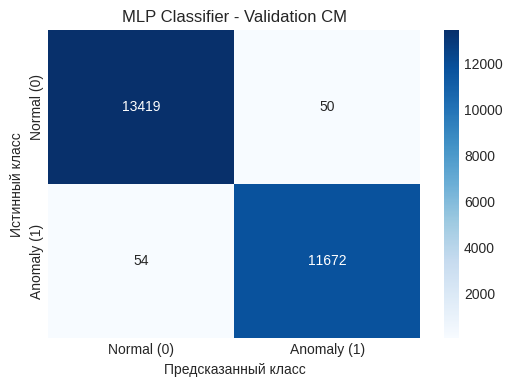

In [ ]:
# Оценка на валидационном наборе
y_val_proba_mlp = mlp_model.predict(X_val_processed, verbose=0).ravel() # ravel() для преобразования в 1D массив
y_val_pred_mlp = (y_val_proba_mlp > 0.5).astype(int) # Порог 0.5

val_roc_auc_mlp = roc_auc_score(y_val, y_val_proba_mlp)
val_f1_anomaly_mlp = f1_score(y_val, y_val_pred_mlp, pos_label=1)

print("\n--- Оценка MLP на валидационном наборе ---")
print(f"Val ROC AUC: {val_roc_auc_mlp:.4f}")
print(f"Val F1-score (аномалия): {val_f1_anomaly_mlp:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_mlp, target_names=['Normal (0)', 'Anomaly (1)']))

print("\nConfusion Matrix:")
cm_mlp = confusion_matrix(y_val, y_val_pred_mlp)
# ... (код для отображения cm_mlp) ...
plt.figure(figsize=(6,4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'MLP Classifier - Validation CM')
plt.show()

In [ ]:
epochs_trained_mlp = early_stopping_mlp.stopped_epoch if early_stopping_mlp.stopped_epoch > 0 else 100
results_summary['MLPClassifier'] = {
    'best_params': {'architecture': '128-64-32-1', 'optimizer': 'adam', 'epochs_trained': epochs_trained_mlp},
    'val_roc_auc': val_roc_auc_mlp,
    'val_f1_anomaly': val_f1_anomaly_mlp,
    'training_time_total_gs': training_time_mlp, # Просто время fit
    'estimator': mlp_model
}

# 8. Оценка моделей на валидационном наборе.

In [ ]:


# 9.1. Сводная таблица результатов

# Убедимся, что results_summary существует и заполнен
if 'results_summary' not in globals() or not results_summary:
    print("Словарь results_summary не найден или пуст. Пожалуйста, убедитесь, что модели были обучены и их результаты сохранены.")
else:
    # Преобразуем словарь результатов в DataFrame
    results_df = pd.DataFrame.from_dict(results_summary, orient='index')
    results_df = results_df.sort_values(by='val_roc_auc', ascending=False) # Сортируем по ROC AUC на валидации

    print("--- Сводная таблица результатов моделей на валидационном наборе ---")
    # Выберем наиболее интересные колонки для отображения
    # (best_cv_roc_auc может быть None для моделей без GridSearchCV, например, IF, AE)
    columns_to_display = ['val_roc_auc', 'val_f1_anomaly', 'best_cv_roc_auc',
                          'training_time_total_gs', 'training_time_fold_mean', 'best_params']

    # Отфильтруем колонки, которые существуют в DataFrame
    existing_columns_to_display = [col for col in columns_to_display if col in results_df.columns]

    display(results_df[existing_columns_to_display])

    # Выбор лучшей модели (или нескольких)
    if not results_df.empty:
        best_model_name = results_df.index[0]
        best_model_entry = results_summary[best_model_name]
        best_model_estimator = best_model_entry['estimator'] # Это обученный пайплайн или модель
        print(f"\n--- Лучшая модель по ROC AUC на валидации: {best_model_name} ---")
        print(f"ROC AUC на валидации: {best_model_entry.get('val_roc_auc', 'N/A'):.4f}")
        print(f"F1 (аномалия) на валидации: {best_model_entry.get('val_f1_anomaly', 'N/A'):.4f}")
        print(f"Лучшие параметры: {best_model_entry.get('best_params', 'N/A')}")
        print(f"Общее время обучения/подбора: {best_model_entry.get('training_time_total_gs', 'N/A'):.2f} сек")
    else:
        print("\nНе удалось определить лучшую модель, так как таблица результатов пуста.")
        best_model_name = None
        best_model_estimator = None

--- Сводная таблица результатов моделей на валидационном наборе ---


,val_roc_auc,val_f1_anomaly,best_cv_roc_auc,training_time_total_gs,training_time_fold_mean,best_params
RandomForest,1.000,0.999,1.000,89.066,NaN,"{'clf__max_depth': None, 'clf__min_samples_lea..."
XGBoost,1.000,0.999,1.000,115.462,NaN,"{'clf__colsample_bytree': 0.7, 'clf__learning_..."
MLPClassifier,1.000,0.996,NaN,76.182,NaN,"{'architecture': '128-64-32-1', 'optimizer': '..."
LogisticRegression,0.996,0.970,0.997,145.316,NaN,"{'clf__C': 10, 'clf__solver': 'liblinear'}"
SGDClassifier,0.996,0.969,0.995,17.452,NaN,"{'clf__alpha': 0.001, 'clf__loss': 'hinge', 'c..."
Autoencoder,0.986,0.919,NaN,54.006,NaN,"{'architecture': '64-32-64', 'threshold_percen..."
GaussianNB,0.979,0.917,0.980,9.941,NaN,{'clf__var_smoothing': 0.0001}
IsolationForest,NaN,NaN,NaN,0.689,0.689,"{'n_estimators': 100, 'contamination': 0.46541..."



--- Лучшая модель по ROC AUC на валидации: RandomForest ---
ROC AUC на валидации: 1.0000
F1 (аномалия) на валидации: 0.9990
Лучшие параметры: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Общее время обучения/подбора: 89.07 сек


# 9. Финальное обучение и тестирование выбранных моделей

--- Финальное обучение и тестирование моделей ---


--- Тестирование модели: RandomForest ---
Обучение RandomForest на полном data_train...
Время финального обучения RandomForest: 9.46 сек

--- Оценка RandomForest на тестовом наборе (data_test) ---
Test ROC AUC: 0.9603
Test F1-score (аномалия): 0.7448

Test Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.65      0.97      0.78      9711
 Anomaly (1)       0.97      0.61      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544


Test Confusion Matrix:


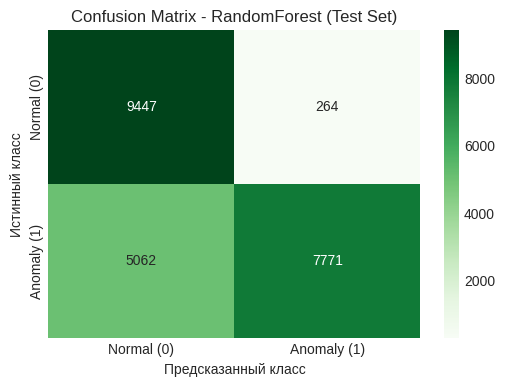



--- Тестирование модели: XGBoost ---
Обучение XGBoost на полном data_train...
Время финального обучения XGBoost: 1.43 сек

--- Оценка XGBoost на тестовом наборе (data_test) ---
Test ROC AUC: 0.9719
Test F1-score (аномалия): 0.7905

Test Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.69      0.97      0.81      9711
 Anomaly (1)       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544


Test Confusion Matrix:


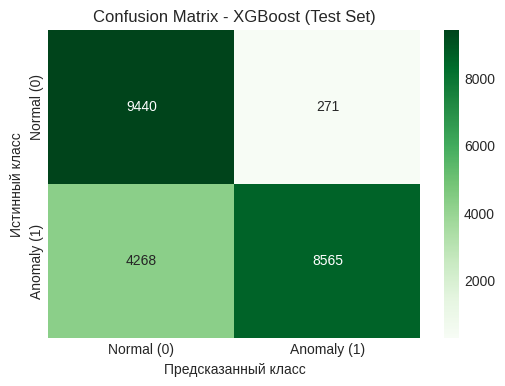



--- Тестирование модели: MLPClassifier ---
Модель MLPClassifier не является пайплайном GridSearchCV или требует специальной обработки для финального обучения.


--- Сводка результатов на ТЕСТОВОМ наборе ---


,test_roc_auc,test_f1_anomaly
RandomForest,0.960,0.745
XGBoost,0.972,0.791
